# 1. Import Libraries

In [1]:
import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime

# 2. File Paths

In [2]:
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

data_dir = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
save_dir = os.path.abspath(os.path.join('..', 'Data', 'SavedModels'))
loss_history_dir = os.path.abspath(os.path.join('..', 'Data','LossHistory'))
visualization_dir = os.path.abspath(os.path.join('..', 'Data','Visualization'))

# 3. Load Models & Data

## 1. Data

In [3]:
# Load matriks rating (data latih)
train_data = np.load(os.path.join(data_dir, 'train_data.npy')).astype(np.float32)

# Mengambil jumlah item (film) untuk layer output VAE
num_items = train_data.shape[1]

## 2. Models

In [4]:
from model import Encoder, Decoder, VAE, RSVD, KLAnnealingCallback

# 4. Training

## 1. VAE

### 1. Import Hyperparameters
    Load hyperparameter terbaik dari Hyperparameter Tuning

In [5]:
vae_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_vae_mul.json')
with open(vae_progress_file, 'r') as f:
    best_vae_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang VAE dengan parameter terbaik: {best_vae_params}")


[INFO] Melatih ulang VAE dengan parameter terbaik: {'latent_dim': 100, 'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.1, 'beta': 0.01, 'hidden_dims': [1024, 512]}


### 2. Construct Model

In [6]:
# Membangun arsitektur Encoder dan Decoder
encoder = Encoder(hidden_dims=best_vae_params['hidden_dims'], latent_dim=best_vae_params['latent_dim'], dropout_rate=best_vae_params['dropout_rate'])
decoder = Decoder(hidden_dims=best_vae_params['hidden_dims'][::-1], output_dim=num_items)

# Inisialisasi VAE dengan beta=0.0 agar KL annealing mulai dari nol
final_vae = VAE(encoder, decoder, beta=0.0)

# Inisialisasi bobot awal agar tensorflow mengenali dimensi data
_ = final_vae(train_data[:1])

# Kompilasi model dengan optimizer Adam dan learning rate terbaik
optimizer = tf.keras.optimizers.Adam(learning_rate=best_vae_params['learning_rate'])
final_vae.compile(optimizer=optimizer)

# Jumlah epoch untuk menaikkan beta dari 0 ke beta_target secara linear.
# Nilai 30 dipilih sebagai ~30% dari estimasi epoch konvergensi (88 epoch sebelumnya),
# memberi model cukup waktu untuk mempelajari rekonstruksi sebelum KL mulai dipaksakan.
KL_ANNEALING_EPOCHS = 30

# Callback KL annealing: naikkan beta bertahap dari 0 → best_vae_params['beta']
kl_annealing = KLAnnealingCallback(
    beta_target=best_vae_params['beta'],
    annealing_epochs=KL_ANNEALING_EPOCHS
)

# Early stopping agar training berhenti jika loss tidak turun selama 10 iterasi
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=10, restore_best_weights=True, verbose=1
)

### 3. Training Model

In [7]:
# Latih VAE dengan matriks rating asli
history = final_vae.fit(
    train_data, train_data, 
    epochs=500,
    batch_size=best_vae_params['batch_size'], 
    # kl_annealing diletakkan sebelum early_stopping agar beta sudah
    # diperbarui di awal epoch sebelum loss dihitung
    callbacks=[kl_annealing, early_stopping],
    verbose=1 # Tampilkan progress bar untuk melihat pergerakannya
)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - kl_loss: 6.1215 - loss: 90.5757 - reconstruction_loss: 90.5145  
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 0.9945 - loss: 71.3274 - reconstruction_loss: 71.3175
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 3.3810 - loss: 68.9326 - reconstruction_loss: 68.8988
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 8.7496 - loss: 66.3708 - reconstruction_loss: 66.2833
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 18.9979 - loss: 63.1986 - reconstruction_loss: 63.0086
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 27.2847 - loss: 60.6174 - reconstruction_loss: 60.3446
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_loss: 37.6731 - loss: 58.0604 - reconstruction_loss: 57.6836
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 44.2860 - loss: 55.9039 - reconstruction_loss: 55.4610
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - kl_l

### 4. Save Weights
    Simpan bobot model setelah selesai training

In [8]:
final_vae.save_weights(os.path.join(save_dir, 'trained_best_vae_weights_mul.weights.h5'))
print("[SUCCESS] Bobot VAE Final berhasil disimpan!")

[SUCCESS] Bobot VAE Final berhasil disimpan!


### 5. Save Loss History
    Simpan riwayat loss untuk visualisasi

In [9]:
vae_history_dict = {'loss': history.history['loss']}

with open(os.path.join(loss_history_dir, 'final_vae_loss_history_mul.json'), 'w') as f:
    json.dump(vae_history_dict, f)

### 6. Latent Matrix Z
    Get latent matrix from VAE for training RSVD

In [10]:
# z_mean, _ = final_vae.encoder.predict(train_data, batch_size=best_vae_params['batch_size'])
# latent_matrix_Z_final = z_mean

## 2. RSVD

### 1. Import Hyperparameters
    Load hyperparameter terbaik dari Hyperparameter Tuning

In [11]:
rsvd_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_file, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang RSVD dengan parameter terbaik: {best_rsvd_params}")


[INFO] Melatih ulang RSVD dengan parameter terbaik: {'n_factors': 10, 'learning_rate': 0.005, 'lambda_reg': 0.001}


### 2. Construct Model
    Inisialisasi model RSVD

In [12]:
final_rsvd = RSVD(
    n_factors=best_rsvd_params['n_factors'], 
    learning_rate=best_rsvd_params['learning_rate'], 
    lambda_reg=best_rsvd_params['lambda_reg'], 
    epochs=100 # Naik drastis agar dekomposisi sempurna
)

### 3. Training Model

In [13]:
# Train dengan data asli
final_rsvd.fit(train_data)

# Mengambil loss dari evaluasi akhir array
final_total_loss = final_rsvd.loss_history[-1]
print(f"Training selesai. Final total loss pada iterasi terakhir: {final_total_loss:.4f}")

[INFO] Total rating     : 80,000
[INFO] Training ratings : 72,000
[INFO] Validation ratings: 8,000
Epoch 001/100 | Train MSE: 0.040869 | Val MSE: 0.041998 | L2: 0.260719 | Total Loss: 0.301588
Epoch 002/100 | Train MSE: 0.038213 | Val MSE: 0.039815 | L2: 0.259427 | Total Loss: 0.297639
Epoch 003/100 | Train MSE: 0.036922 | Val MSE: 0.038810 | L2: 0.258285 | Total Loss: 0.295207
Epoch 004/100 | Train MSE: 0.036119 | Val MSE: 0.038209 | L2: 0.257270 | Total Loss: 0.293389
Epoch 005/100 | Train MSE: 0.035555 | Val MSE: 0.037800 | L2: 0.256363 | Total Loss: 0.291919
Epoch 006/100 | Train MSE: 0.035132 | Val MSE: 0.037501 | L2: 0.255550 | Total Loss: 0.290682
Epoch 007/100 | Train MSE: 0.034801 | Val MSE: 0.037275 | L2: 0.254818 | Total Loss: 0.289619
Epoch 008/100 | Train MSE: 0.034534 | Val MSE: 0.037098 | L2: 0.254158 | Total Loss: 0.288692
Epoch 009/100 | Train MSE: 0.034314 | Val MSE: 0.036957 | L2: 0.253561 | Total Loss: 0.287875
Epoch 010/100 | Train MSE: 0.034130 | Val MSE: 0.036844

### 4. Save Weights
    Simpan bobot setelah training

In [14]:
np.save(os.path.join(save_dir, 'final_mu_mul.npy'), np.array(final_rsvd.mu))
np.save(os.path.join(save_dir, 'final_b_u_mul.npy'), final_rsvd.b_u)
np.save(os.path.join(save_dir, 'final_b_i_mul.npy'), final_rsvd.b_i)
np.save(os.path.join(save_dir, 'best_U_mul.npy'), final_rsvd.U)
np.save(os.path.join(save_dir, 'best_Sigma_mul.npy'), final_rsvd.Sigma)
np.save(os.path.join(save_dir, 'best_V_mul.npy'), final_rsvd.V)
print("[SUCCESS] Matriks RSVD Final berhasil disimpan!")

[SUCCESS] Matriks RSVD Final berhasil disimpan!


### 5. Save Loss History
    Simpan riwayat loss untuk visualisasi

In [15]:
np.save(os.path.join(loss_history_dir, 'final_rsvd_loss_history_mul.npy'), final_rsvd.loss_history)

# 5. Training Visualization

## 1. Import Loss History

### 1. VAE

In [16]:
# Load riwayat loss VAE
try:
    with open(os.path.join(loss_history_dir, 'final_vae_loss_history_mul.json'), 'r') as f:
        vae_loss_history = json.load(f)['loss']

except FileNotFoundError as e:
    print(f"[ERROR] Could not find the history files. Details: {e}")

### 2. RSVD

In [17]:
# Load riwayat loss RSVD
rsvd_loss_history = np.load(os.path.join(loss_history_dir, 'final_rsvd_loss_history_mul.npy'))

## 2. Visualization


[SUCCESS] Gambar grafik beresolusi tinggi (High-Res) berhasil disimpan di: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\Visualization\final_training_curves_20260312_2139.png


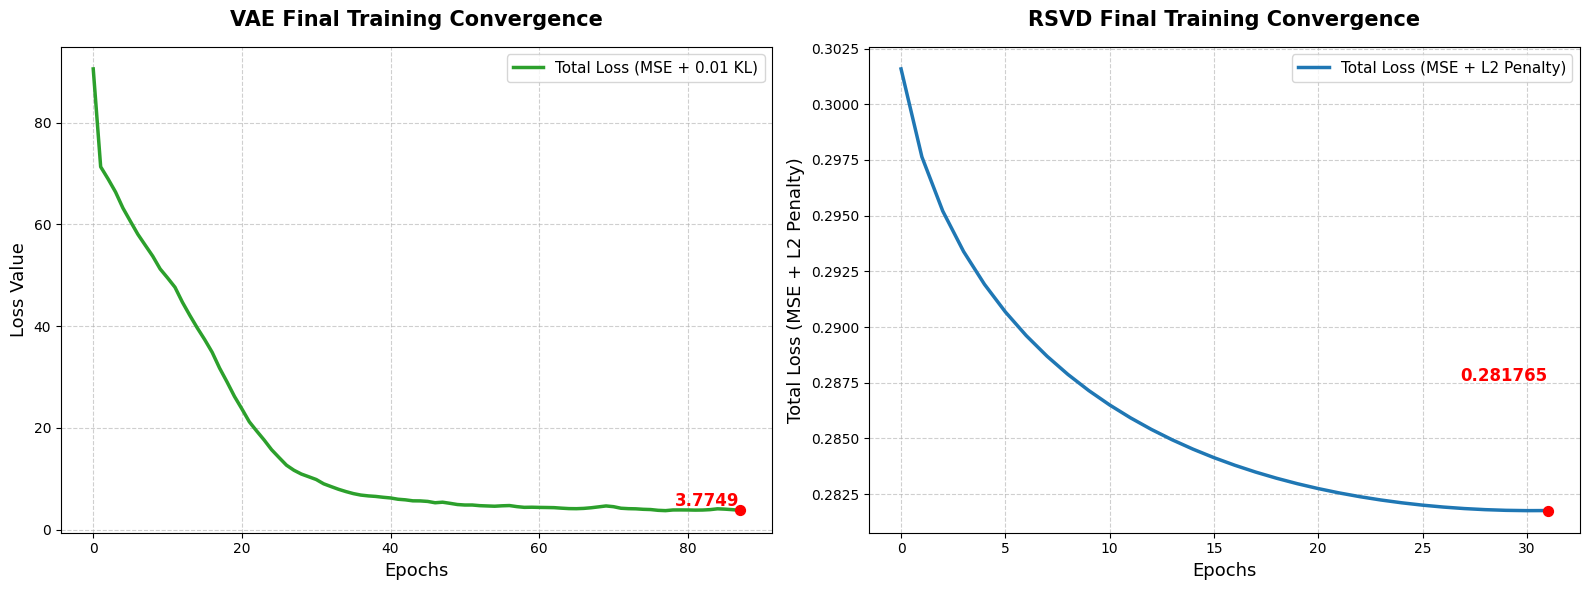

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
# ==========================================
# PLOT 1: KURVA LOSS VAE
# ==========================================
ax1 = axes[0]
# PERBAIKAN: Mengubah label menjadi (MSE + Beta KL) sesuai modifikasi fungsi loss di proposal
beta_val = best_vae_params.get('beta', 'β')
ax1.plot(vae_loss_history, label=f'Total Loss (Multinomial NLL + {beta_val} KL)', color='#2ca02c', linewidth=2.5)

# Menandai titik epoch terakhir dengan scatter merah
vae_final_epoch = len(vae_loss_history) - 1
vae_final_loss = vae_loss_history[-1]
ax1.scatter(vae_final_epoch, vae_final_loss, color='red', s=50, zorder=5)
ax1.text(vae_final_epoch, vae_final_loss + (vae_final_loss * 0.02), f'{vae_final_loss:.4f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax1.set_title('VAE Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=13)
ax1.set_ylabel('Loss Value', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11)

# ==========================================
# PLOT 2: KURVA MSE RSVD
# ==========================================
ax2 = axes[1]
ax2.plot(rsvd_loss_history, label='Total Loss (MSE + L2 Penalty)', color='#1f77b4', linewidth=2.5)

# Menandai titik epoch terakhir dengan scatter merah
rsvd_final_epoch = len(rsvd_loss_history) - 1
rsvd_final_loss = rsvd_loss_history[-1]
ax2.scatter(rsvd_final_epoch, rsvd_final_loss, color='red', s=50, zorder=5)
ax2.text(rsvd_final_epoch, rsvd_final_loss + (rsvd_final_loss * 0.02), f'{rsvd_final_loss:.6f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax2.set_title('RSVD Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=13)
ax2.set_ylabel('Total Loss (MSE + L2 Penalty)', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11)

# ==========================================
# FINALISASI DAN PENYIMPANAN GAMBAR
# ==========================================
plt.tight_layout()

# Menyimpan gambar dengan resolusi tinggi (300 dpi) agar tajam saat dimasukkan ke PDF/Word Skripsi
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
plot_path = os.path.join(visualization_dir, f'final_training_curves_{timestamp}.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n[SUCCESS] Gambar grafik beresolusi tinggi (High-Res) berhasil disimpan di: {plot_path}")

plt.show()